In [62]:
# Import Packages
import pandas as pd
import copy as c
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [63]:
df_dataset = pd.read_csv("./data/job_market_dataset.csv")
c_df = c.deepcopy(df_dataset)

#### Average Salary For Each Departement

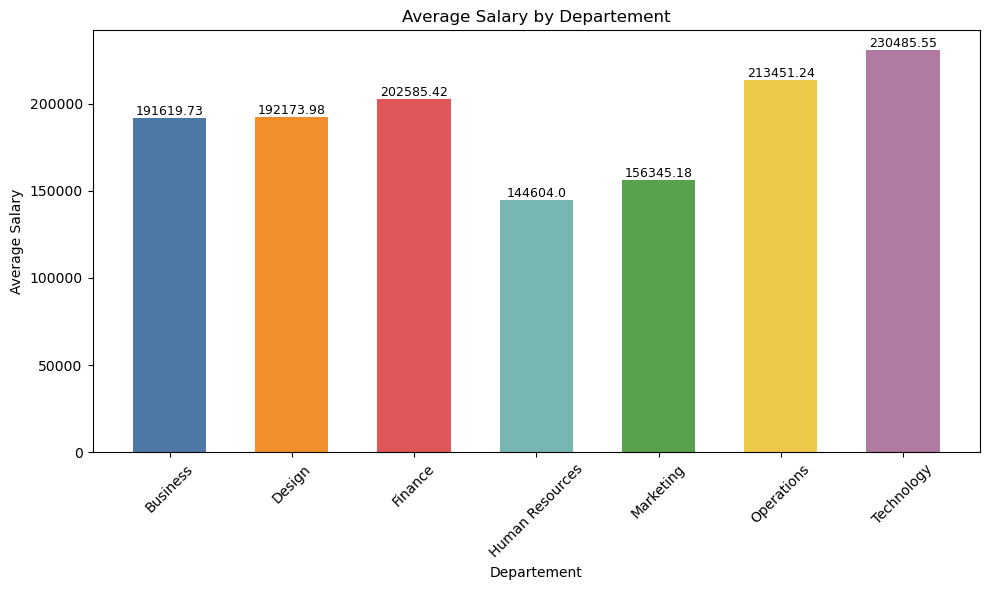

In [64]:
# Prepare data by DataFrame that Has Filed With Salaary
df_salary_field = pd.concat([c_df["field"], c_df["salary"]], axis=1)
df_group = df_salary_field.groupby("field")["salary"].mean().round(2)

salary_list = df_group.values
departement_list = df_group.index

# Define Colors
bar_colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1"]

# Plot bars
plt.figure(figsize=(10,6))
bars = plt.bar(departement_list, salary_list, color=bar_colors, width=0.6)

# Define Labels and title
plt.xlabel("Departement")
plt.ylabel("Average Salary")
plt.title("Average Salary by Departement")
plt.xticks(rotation=45)

# Show salary as number on each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### Top Hiring Countries

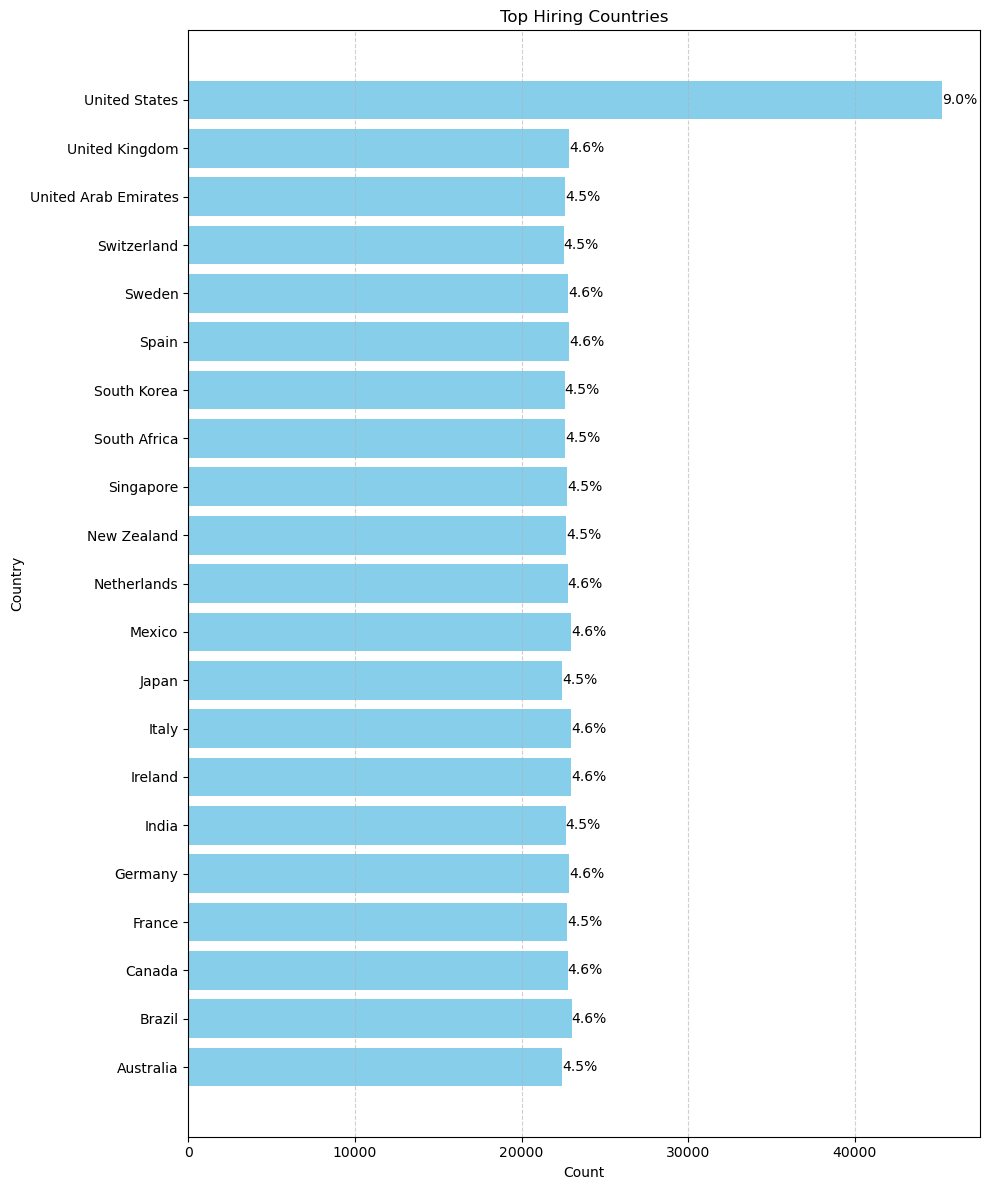

In [65]:
# Get Number Of Employees for Each Country
df_country = pd.DataFrame(c_df["country"])
df_group_by_country = df_country.groupby(by=["country"]).size().reset_index(name="count")

# Plot Bars
size_dataset = c_df["country"].count()

country_list = df_group_by_country["country"].to_list()
count_list = df_group_by_country["count"].to_list()

plt.figure(figsize=(10,12))
plt.barh(country_list, count_list, color="skyblue")
for i, v in enumerate(count_list):
    percent = (v * 100) / size_dataset
    plt.text(v + 0.2, i, f"{percent:.1f}%", va='center')  # shows 1 decimal
plt.xlabel("Count")
plt.ylabel("Country")
plt.title("Top Hiring Countries")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

#### Experience vs Salary

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise,2023,9
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large,2024,12
4,United States,New York,Cloud Engineer,Technology,4,330618.0,part_time,Master,Male,Enterprise,2022,1


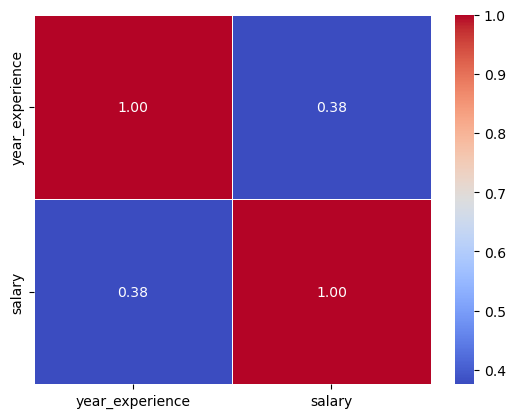

In [66]:
# Correlation
'''
    Correlation: Static concept that mesure relation between two vraibles:
        --> Positive Correlation: both variables increase or decrease together
        --> Zero Correlation: one variable increases while the other decreases
        --> Negative Correlation: No Relation Between Two Varaibles
'''

# Make DataFrame For Years of Expeience and Salary
df_year_experience = pd.DataFrame(c_df["years_of_experience"])
df_salary = pd.DataFrame(c_df["salary"])

df_year_experience_salary = pd.concat([df_year_experience, df_salary], ignore_index=True, axis=1)
df_year_experience_salary.rename(columns={0: "year_experience", 1: "salary"}, inplace=True)
df_year_experience_salary

# Get Correlation Between Salary and Experience
correlation = df_year_experience_salary.corr(method="pearson")



sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

c_df.head()

How does experience impact salary?
As we can see, the relationship between years of experience and salary is weak. This is normal because there are other contributing factors, such as the country of employment, work arrangement (on-site, remote, or part-time), and the size of the company.

#### Female/Male for Each Deperatement

In [ ]:
# Get DataSet For Make
df_male = c_df.where(c_df["gender"] == "Male").dropna()
df_male
# Get DataSet For Female
df_female = c_df.where(c_df["gender"] == "Female").dropna()
df_female
# Get DataSet For Others
df_other = c_df.where(c_df["gender"] == "Other").dropna()
df_other

# Get For Each Departement Percentage of Gender --> Male
df_male.groupby(by="occupation")["gender"].count()

# Get For Each Departement Percentage of Gender --> Female
df_female.groupby(by="occupation")["gender"].count()

# Get For Each Departement Percentage of Gender --> Other
df_other.groupby(by="occupation")["gender"].count()

# Display for Each Gender Existance Percentage for Each Departement



occupation
AI Engineer             13865
Business Analyst        13846
Cloud Engineer          13982
Data Analyst            13975
Data Scientist          13892
Financial Analyst       13936
HR Analyst              13961
Marketing Specialist    13835
Operations Manager      13892
Product Manager         14098
Software Engineer       14199
UX Designer             14020
Name: gender, dtype: int64

In [68]:
'''
    Problem Statement
        The objective of this project is to analyze salary patterns across various job roles and experience
            levels to answer key questions such as:

        - How does experience impact salary?
        - Which job roles offer higher compensation?
        - How do salaries vary across locations and employment types?
'''

# Who Person Work From Home (year_experience, filied, country, )
# --> remote --> person from X, year_exper (just intervall), education level, 
# Number Of Female/Male for Each Deperatement

'\n    Problem Statement\n        The objective of this project is to analyze salary patterns across various job roles and experience\n            levels to answer key questions such as:\n\n        - How does experience impact salary?\n        - Which job roles offer higher compensation?\n        - How do salaries vary across locations and employment types?\n'